## PAW wavelet decomposition

In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import pandas as pd
from one.api import ONE
from scipy import stats

# Get my functions
from segmentation_functions import idxs_from_files, fast_wavelet_morlet_convolution_parallel, get_speed
one = ONE(mode='remote')

In [5]:
""" 
LOAD DATA AND PARAMETERS
"""
# LOAD DATA

data_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/segmentation/design_matrices/'
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'
# data_path = prefix + 'representation_learning_variability/paper-individuality/segmentation/1_camera_setup/temp_data/design_matrices/'
data_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/design_matrices/1_camera_setup/NM/' # session_1
# data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/1_camera_setup/extra_bwm/'

results_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/segmentation/paw_wavelets/'
results_path = prefix + 'representation_learning_variability/paper-individuality/data/paw_wavelets/'
results_path = "/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/training/session_1/paw_wavelets/"

# results_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/'
results_path = prefix + 'representation_learning_variability/paper-individuality/data/neuromodulators/left_paw_wavelets/'

all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

# Wavelet decomposition
f = np.array([.25, .5, 1, 2, 4, 8, 16, 32])
omega0 = 5
velocity = True

In [6]:
# Loop through animals
files = os.listdir(results_path)
sessions_to_process = []

for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]

    """ SAVE DATA """       
    # Save wavelets
    if velocity:
        subname = "paw_vel_wavelets_"
    else:
        subname = "paw_pos_wavelets_"
    filename = subname + str(session) + '_'  + mouse_name

    if filename not in files:
        sessions_to_process.append((session))

len(sessions_to_process)

91

### Exclude bad proficient sessions

In [13]:
# sessions_to_exclude = ['2d7c0f7f-e805-404b-914a-23d83998e08e', # bad right cam
# '7691eeb3-715b-4571-8fda-6bb57aab8253', # bad view of paws
# 'bd8b204f-a42e-45c1-a8f0-71c6223a6657', # bad right camera
# 'f3eeb2d4-87ce-49ae-8a74-21665f6f1536', # moving licks
# '650a0a90-4bf3-4489-9bcd-75baf0a49eac', # licks fail
# '495bee7e-b58e-42ea-8481-4a1bfedca54a', # timestamps
# '1db57661-5ad3-4465-b9ee-08473af9c2e8', # timestamps
# '6a369bfa-a70b-4147-af25-d03772ff8d96', # timestamps
# '7050ae29-a99e-43f1-aa42-b4416200351c', # timestamps
# '3fa080ff-bcce-43e8-bd5f-601f0591f785', # timestamps
# '5c454bcb-ae77-42da-a8d2-b6463ea9f21b', # bad licks
# 'c728f6fd-58e2-448d-aefb-a72c637b604c' # no data can be loaded
# ]

# sessions_to_exclude = [
# '30af8629-7b96-45b7-8778-374720ddbc5e',
# '90e524a2-aa63-47ce-b5b8-1b1941a1223a',
# 'a8a8af78-16de-4841-ab07-fde4b5281a03',
# '49368f16-de69-4647-9a7a-761e94517821',
# 'a71175be-d1fd-47a3-aa93-b830ea3634a1',
# '0deb75fb-9088-42d9-b744-012fb8fc4afb',
# '02fbb6da-3034-47d6-a61b-7d06c796a830',
# '7f6b86f9-879a-4ea2-8531-294a221af5d0',
# '8c33abef-3d3e-4d42-9f27-445e9def08f9',
# 'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
# '510b1a50-825d-44ce-86f6-9678f5396e02']

sessions_to_exclude = ['a8a8af78-16de-4841-ab07-fde4b5281a03',
    '8c33abef-3d3e-4d42-9f27-445e9def08f9',
    'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
    # '0deb75fb-9088-42d9-b744-012fb8fc4afb',  # bad fit (should not be excluded here)
    # 'a71175be-d1fd-47a3-aa93-b830ea3634a1',  # bad fit (should not be excluded here)
    '91bac580-76ed-41ab-ac07-89051f8d7f6e',
    '8a1cf4ef-06e3-4c72-9bc7-e1baa189841b',
    # '02fbb6da-3034-47d6-a61b-7d06c796a830',  # bad fit (should not be excluded here)
    '64977c74-9c04-437a-9ea1-50386c4996db',
    '90e524a2-aa63-47ce-b5b8-1b1941a1223a',
    '30af8629-7b96-45b7-8778-374720ddbc5e',
    # '510b1a50-825d-44ce-86f6-9678f5396e02',  # bad fit (should not be excluded here)
    'f3eeb2d4-87ce-49ae-8a74-21665f6f1536',
    # '49368f16-de69-4647-9a7a-761e94517821',  # bad fit (should not be excluded here)
    # '7f6b86f9-879a-4ea2-8531-294a221af5d0',  # bad fit (should not be excluded here)
    'fcd49e34-f07b-441c-b2ac-cb8c462ec5ac']  # Ago 7 2026


exclude_training_eids = [
    "b117ed10-6871-42b3-9193-ca708dac4353",  # CHSL045
    "4636ab1e-0522-472b-8eda-69b4223677c7",  # NR0019
    "167f98be-6704-430f-b531-2d4ab2aae932",  # NR_0027
    "75e5c60b-462c-4a00-ae04-77baf489bdef",  # NYU-40
    "ed9fca43-8b3e-414d-baf3-caeed8edd0ac",  # NYU-46
    "70ec358f-a55b-4b28-9a7a-0a674012930f",  # NYU-47
    "f1ee85e7-f863-4648-b32f-9c7b90cc3fdf",  # PL017
    "a53fed99-d34c-4bf5-a7ec-c0ff7e6350f3",  # PL030
    "6a6670e3-56a5-4d37-8e07-14262f954f3f",  # PL031
    "cda5ec4d-f5a3-4cbc-8547-40b57c840d92",  # PL033
    "158e13ee-8eb6-4473-aa3c-1f940b004570",  # ZFM-01935
]

exclude_extra_bwm_biased_eids = ["e8d4d715-8265-458d-85cd-d096bb4b4c52", 
    "a353b2d7-cd82-44d8-ac8a-f2ea872e79fe", 
    "999ad2ec-0253-40cb-8b5e-8b56b1e1154a", 
    "dcb0bd56-eb5f-44e2-8054-e1892dd84ae7", 
    "c7fac976-508e-4751-9030-835c724e8f5f", 
    "475280aa-4557-418b-bdcd-f90862de9765", 
    "cabef930-ca03-4f53-ae11-48a83d6e1c01", 
    "1a61dd23-1fde-4efb-973c-d473797691d8", 
    "f896bc3b-5496-441a-81bc-c3bb518bad3b", 
    "96bcf9ca-972f-491f-979a-f8b9de2f9477", 
    "bfec1493-4e2c-43b2-80de-e12015495a92", 
    "1b09ca4c-3e18-4409-b42d-a63d7900f35a", 
    "1fc4387b-0da4-49e9-891c-559ad1de3ce4", 
    "1aa9254a-38ff-427a-87d8-c5db81127a77"
    ]

sessions_to_process = [x for x in sessions_to_process if x not in sessions_to_exclude]
len(sessions_to_process)

17

# Paw wavelets

In [7]:
concatenated_subsampled = np.array([])
paws = ['l_paw', 'r_paw']
paws = ['l_paw']

for m, mat in enumerate(sessions_to_process):

    file_path = one.eid2path(mat)
    if prefix == '/home/ines/repositories/':
        mouse_name = file_path.parts[8]
    else:
        mouse_name = file_path.parts[7]

    session = mat
    filename = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)
    
    empirical_frame_rate = np.round(1/np.nanmean(design_matrix['Bin'].diff()))

    if velocity:
        left_speeds = get_speed(design_matrix, design_matrix['Bin'], 'left', empirical_frame_rate, split=True, feature='l_paw')
        right_speeds = get_speed(design_matrix, design_matrix['Bin'], 'right', empirical_frame_rate, split=True, feature='r_paw')
        
    for v, var in enumerate(paws):
        for c, coor in enumerate(['_x', '_y']):
            if velocity:
                # If velocity, no z-score before wavelets
                array = np.array(left_speeds[c+1]) if var=='l_paw' else np.array(right_speeds[c+1])
            else:
                # If position, z-score before wavelets
                design_matrix[var+coor] = stats.zscore(np.array(design_matrix[var+coor]), 
                                                    nan_policy='omit', axis=0)  #stats.zscore(data_df[paw_vars], axis=0)
                array = np.array(design_matrix[var+coor]) 
            not_nan = ~np.isnan(array)
            clean_array = array[not_nan]# np.array(stats.zscore(design_matrix[var][not_nan_x]))
            
            # Wavelet decomposition of paw position
            dt = np.round(np.mean(np.diff(design_matrix['Bin'])), 3)
            amp, Q, x_hat = fast_wavelet_morlet_convolution_parallel(clean_array, f, omega0, dt)

            # Wavelet transforms
            for i, frequency in enumerate(f):
                # Create new column with frequency
                colname = str(var+coor+str(frequency))
                design_matrix.loc[not_nan, colname] = amp[i, :]
                # design_matrix[str(var+coor+str(frequency))] = np.nan
                # design_matrix[str(var+coor+str(frequency))][not_nan] = amp[i, :]

    """ SAVE DATA """       
    # Save wavelets
    if velocity:
        subname = "paw_vel_wavelets_"
    else:
        subname = "paw_pos_wavelets_"
    filename = results_path + subname + str(session) + '_'  + mouse_name
    design_matrix.to_parquet(filename, compression='gzip')  
    print(mat)

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q


f2898cc0-6bfd-4af9-bdc8-58af869dd0be


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q


5bec164a-3eae-4097-9992-a99c62201d53


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q


...

c55e4b10-1bd8-4bbc-97bf-fe1b6467e946


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q


754f8a6b-60ef-480a-9665-5b3428aea365


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q
/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/segmentation_functions.py:633: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[i, :] = q


bc7a39b5-0e99-41e0-ba01-03a1380e1237


# Explore the data

In [ ]:
from matplotlib import pyplot as plt

In [2]:
import seaborn as sns
palette = sns.color_palette('Greys')
use_data = design_matrix.loc[(design_matrix['Bin']> 200) & (design_matrix['Bin']< 500)]
plt.plot(use_data['l_paw_x']/2-400, label='Left paw', color='Blue')
for i, e in enumerate(['l_paw_x0.5','l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0']):
    plt.plot(use_data[e]/2, label=e[-3:]+'Hz', color=palette[i+1])
    plt.legend()
    plt.xlim([8000, 9000])
    plt.ylim([-300, 150])
plt.show()
    
plt.plot(use_data['r_paw_x']-100, label='Right paw', color='Orange')
for i, e in enumerate(['r_paw_x0.5','r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0']):
    plt.plot(use_data[e], label=e[-3:]+'Hz', color=palette[i+1])
    plt.legend()
    plt.xlim([8000, 9000])
    plt.ylim([-50, 500])

NameError: name 'design_matrix' is not defined

## Data exploration

In [8]:
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression

/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


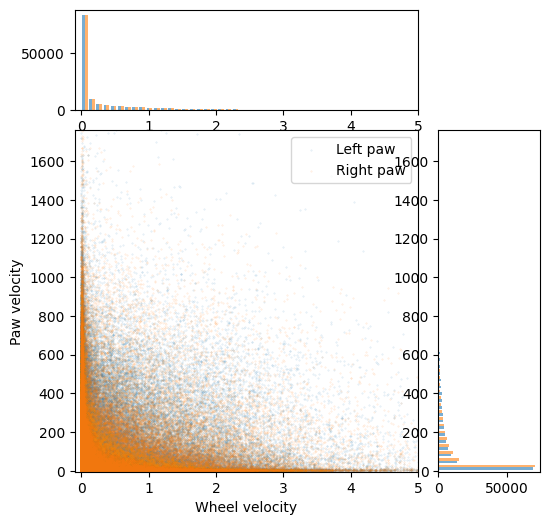

5e3f2342-4952-4894-864f-d7a181072ab5


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


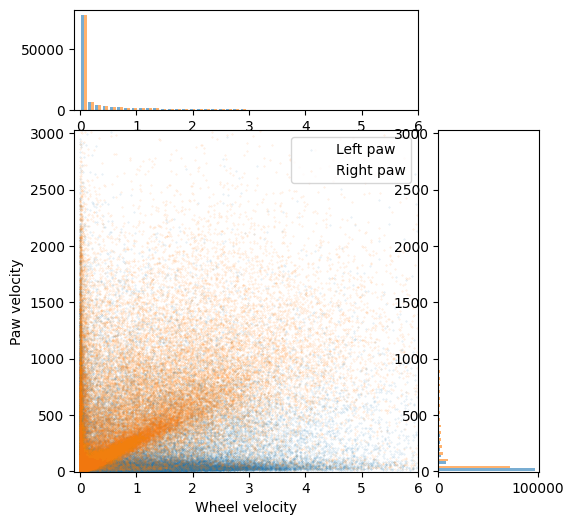

13b70283-e8d3-4e69-ae3f-83f50c9602e2


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


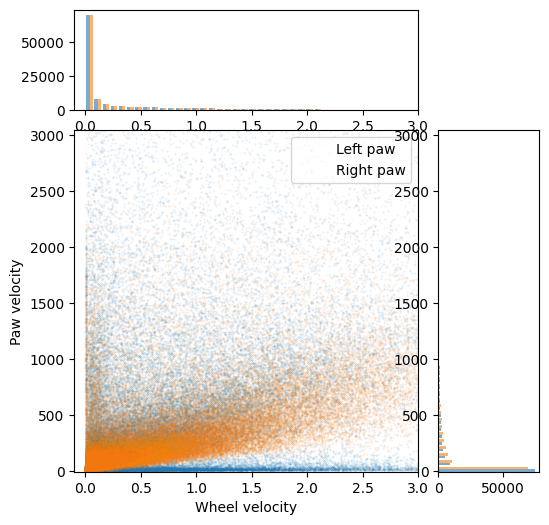

1e56bf02-d888-4259-9484-f6b9e3451997


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


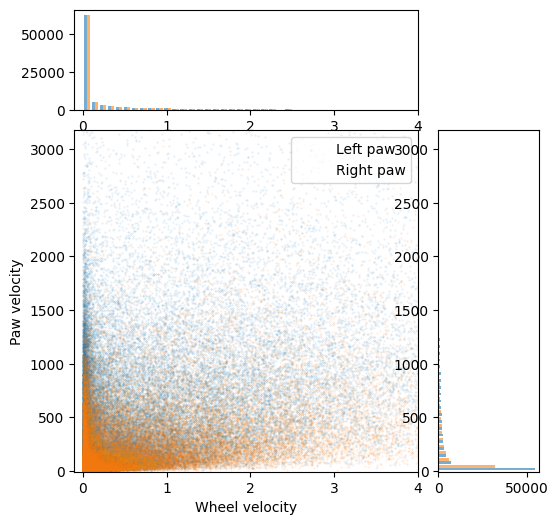

ba5952cb-9219-458f-a153-2a33637beb70


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


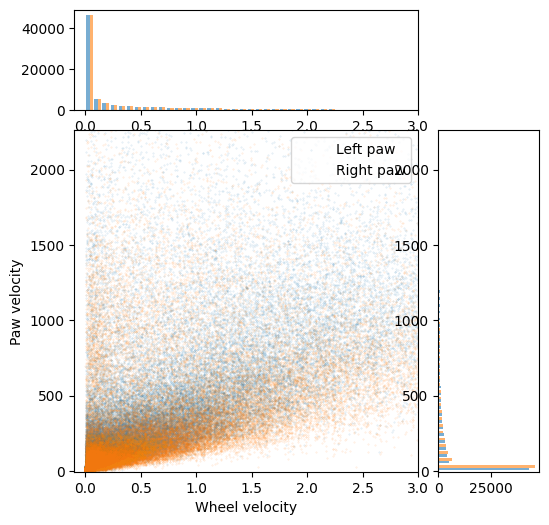

c8337aff-5b94-408d-89b9-b2d9110ac33d


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


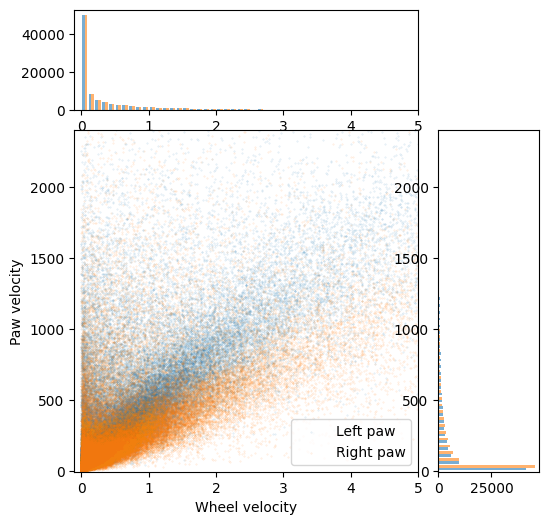

86f741b4-9dee-4c28-8ee9-49f3656ab419


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


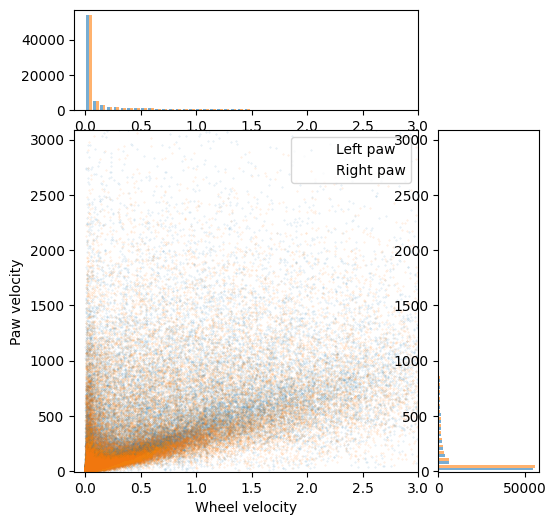

8eb504f7-2023-4d23-911b-345dc8168b01


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


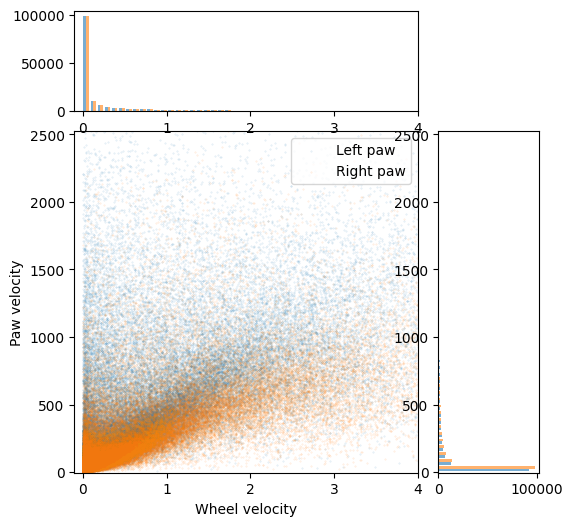

2d7c0f7f-e805-404b-914a-23d83998e08e


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


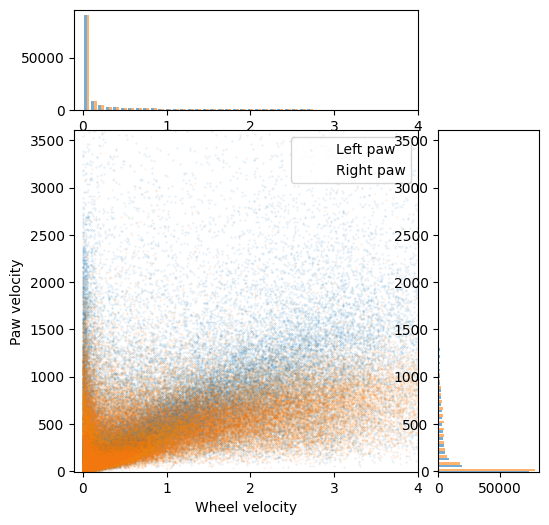

28f37ed6-776f-430b-9b85-8369119a43c8


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


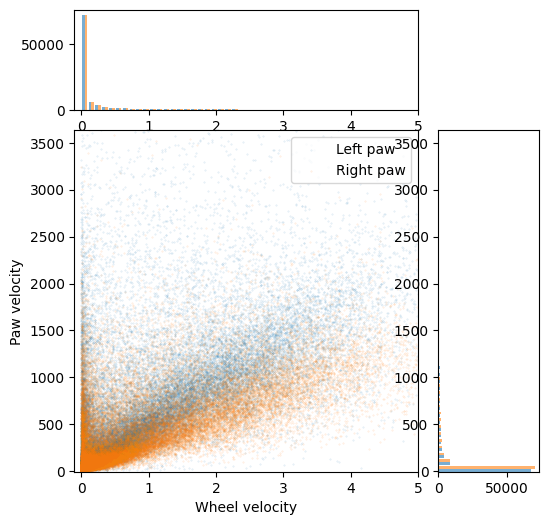

e4fac833-d985-4bb2-a97a-c4d7ed8d06e1


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


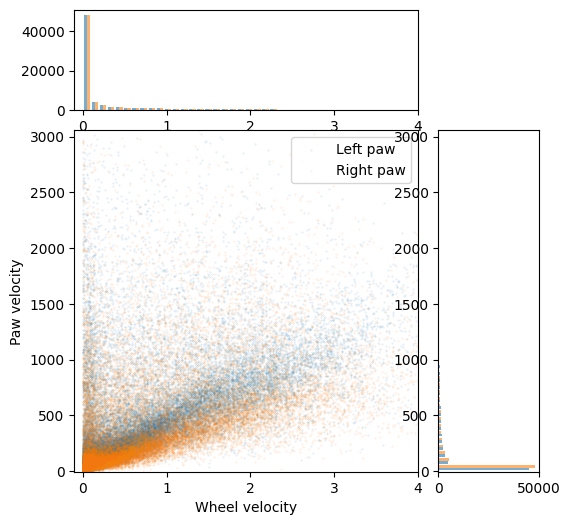

b4260df3-e8e8-46e8-94e2-109a1776619f


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


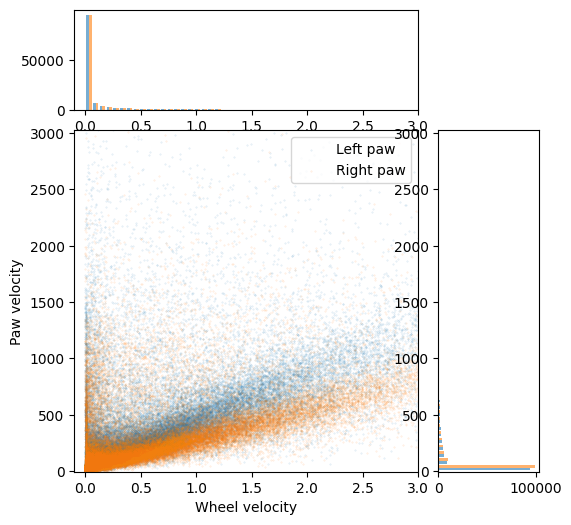

3964f470-99a3-449d-8075-f9b4888d462a


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


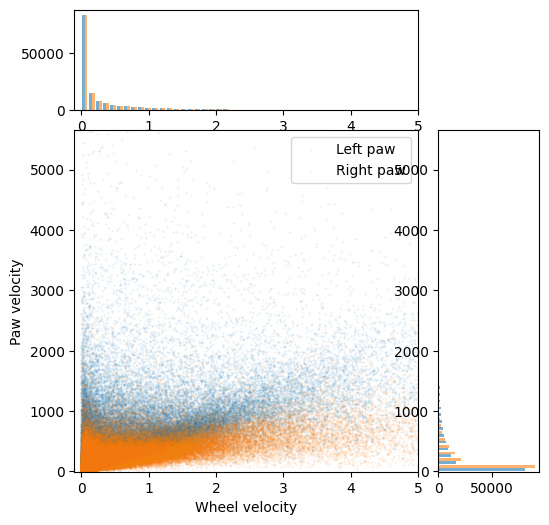

448011c3-70f0-429a-a671-bd5ef743c42f


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


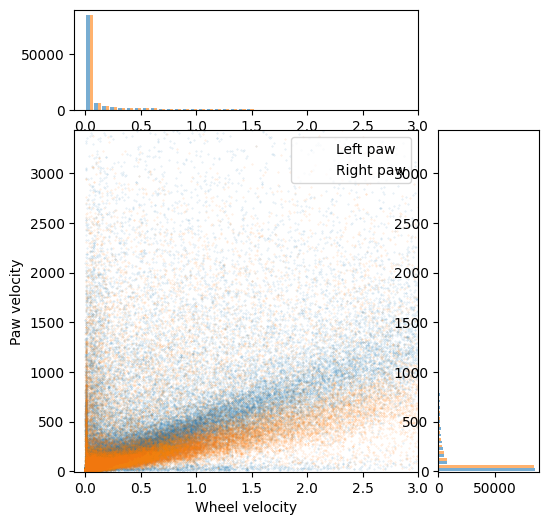

24c7c64b-2494-4b83-8fe9-3adee65abc86


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


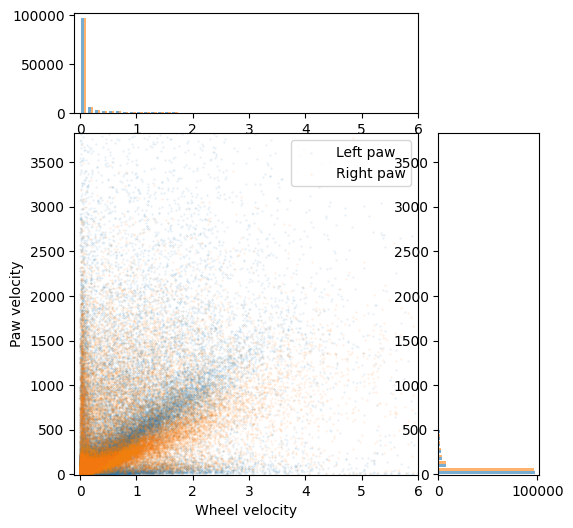

f8d9bc97-61e9-4f90-80e2-40e849fccebe


/tmp/ipykernel_84010/1982844589.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


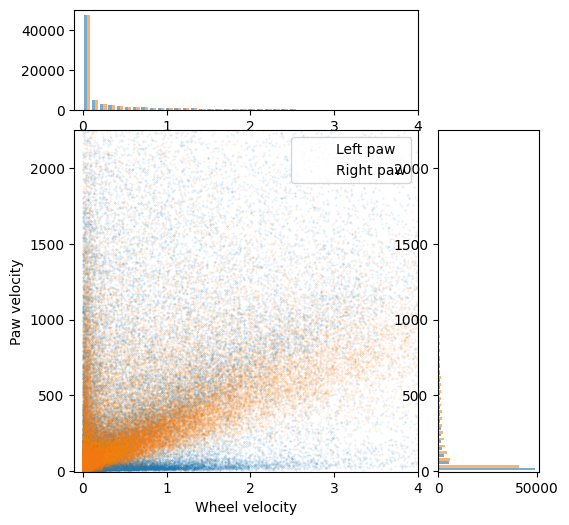

32c515a2-fcea-479a-8828-b57b16e66b46


In [10]:
paws = ['l_paw', 'r_paw']

for m, mat in enumerate(sessions_to_process):

    file_path = one.eid2path(mat)
    if prefix == '/home/ines/repositories/':
        mouse_name = file_path.parts[8]
    else:
        mouse_name = file_path.parts[7]

    session = mat
    filename = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)
    left_speeds = get_speed(design_matrix, design_matrix['Bin'], 'left', 30, split=False, feature='l_paw')
    right_speeds = get_speed(design_matrix, design_matrix['Bin'], 'left', 30, split=False, feature='r_paw')
    
    # Create main figure
    fig = plt.figure(figsize=(6, 6))
    grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)

    # Define areas
    main_ax = fig.add_subplot(grid[1:4, 0:3])
    x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
    y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)

    # Scatterplot (two hues)
    main_ax.scatter(np.abs(design_matrix['avg_wheel_vel']), left_speeds[1], alpha=0.2, s=.1, label='Left paw', color='C0')
    main_ax.scatter(np.abs(design_matrix['avg_wheel_vel']), right_speeds[1], alpha=0.2, s=.1, label='Right paw', color='C1')
    main_ax.legend()
    
    # --- Fit and plot regression lines ---
    x1 = x2 = np.array(np.abs(design_matrix['avg_wheel_vel']))
    y1 = left_speeds[1]
    y2 = right_speeds[1]
    
    # # Fit and plot for each group
    # model = LinearRegression()
    # for x, y, color, label in [(x1, y1, 'C0', 'Group 1'), (x2, y2, 'C1', 'Group 2')]:
    #     model.fit(x.reshape(-1, 1), y)
    #     xs = np.linspace(x.min(), x.max(), 100)
    #     ys = model.predict(xs.reshape(-1, 1))
    #     plt.plot(xs, ys, color=color, linewidth=2)


    main_ax.legend()


    # Marginal histograms
    y_hist.hist([left_speeds[1],right_speeds[1]], bins=100, color=['C0', 'C1'], alpha=0.6, orientation='horizontal')
    x_hist.hist([np.abs(design_matrix['avg_wheel_vel']), np.abs(design_matrix['avg_wheel_vel'])], bins=100, color=['C0', 'C1'], alpha=0.6)

    # Hide tick labels on shared axes
    # x_hist.set_xticks([])
    # y_hist.set_yticks([])
    main_ax.set_ylim([-5, int(np.nanmax([left_speeds[1], right_speeds[1]])/2)])
    main_ax.set_xlim([-.1, int(np.nanmax(np.abs(design_matrix['avg_wheel_vel']))/2)])
    main_ax.set_xlabel('Wheel velocity')
    main_ax.set_ylabel('Paw velocity')
    plt.tight_layout()
    plt.show()
    print(session)


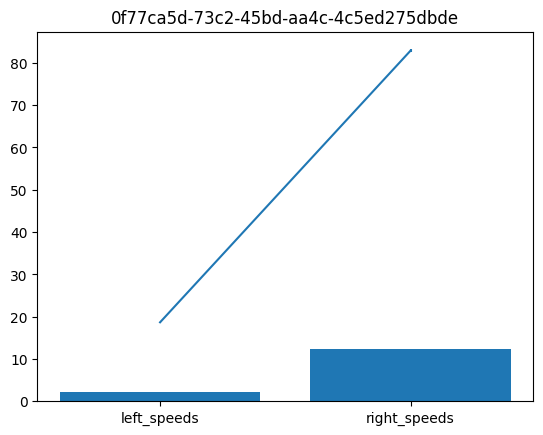

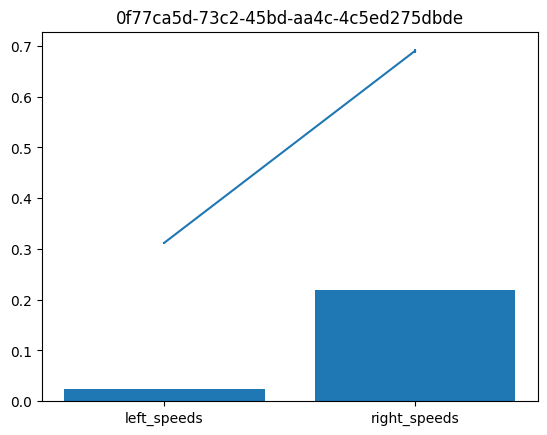

0f77ca5d-73c2-45bd-aa4c-4c5ed275dbde


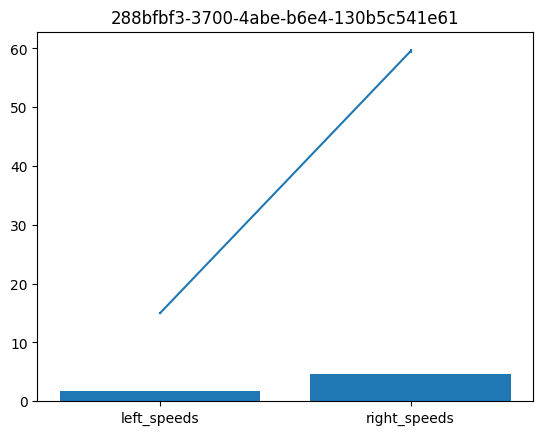

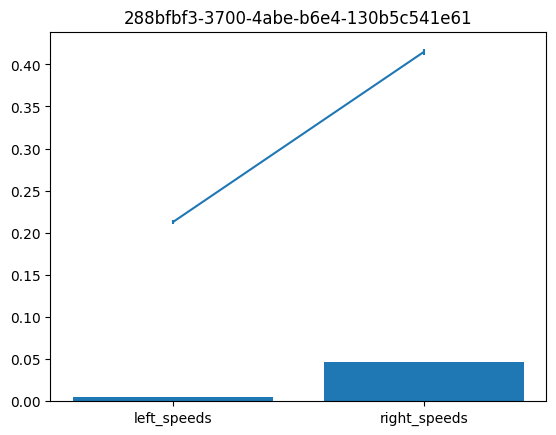

288bfbf3-3700-4abe-b6e4-130b5c541e61


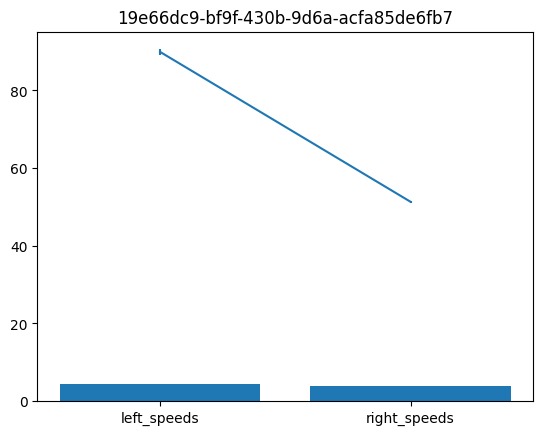

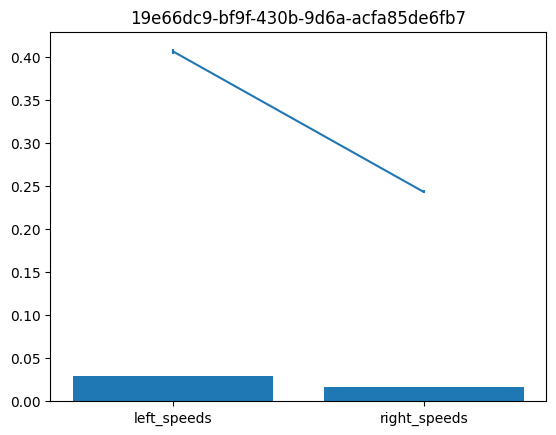

19e66dc9-bf9f-430b-9d6a-acfa85de6fb7


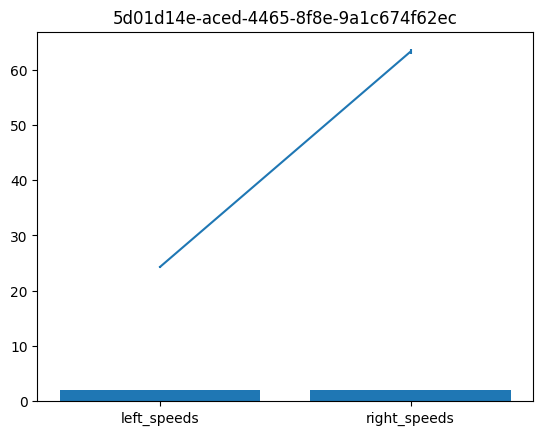

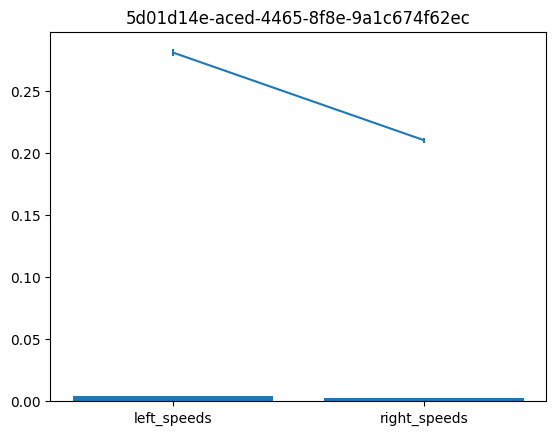

5d01d14e-aced-4465-8f8e-9a1c674f62ec


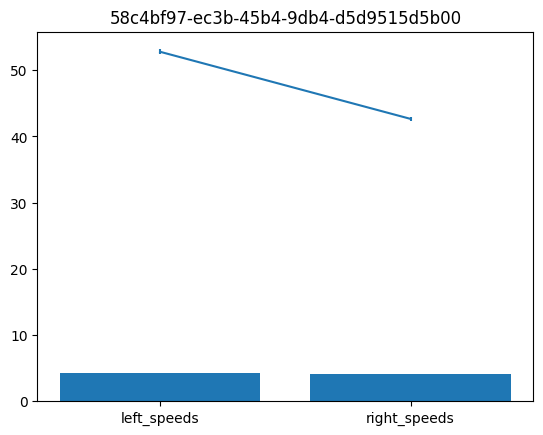

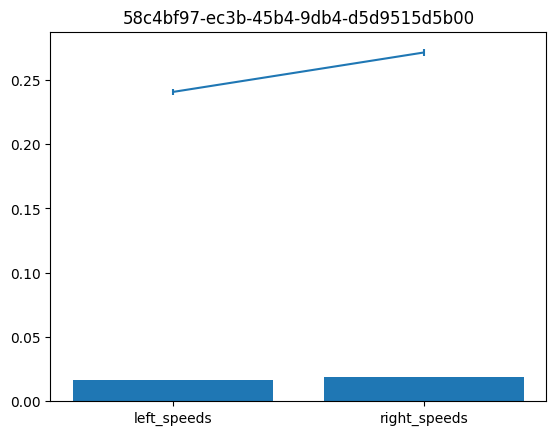

58c4bf97-ec3b-45b4-9db4-d5d9515d5b00


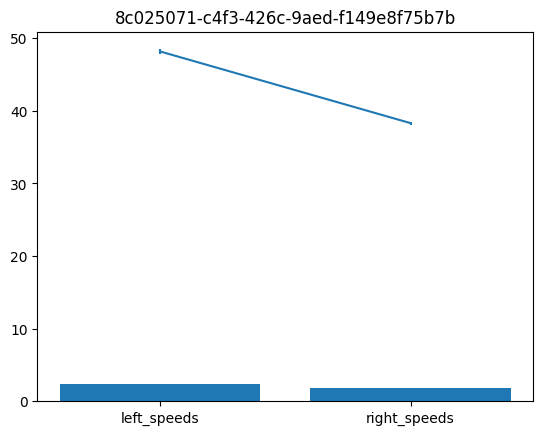

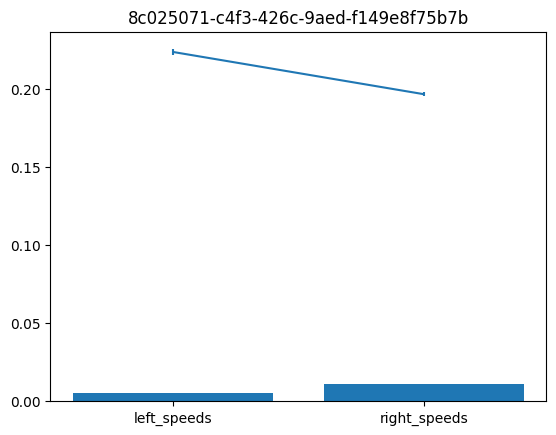

8c025071-c4f3-426c-9aed-f149e8f75b7b


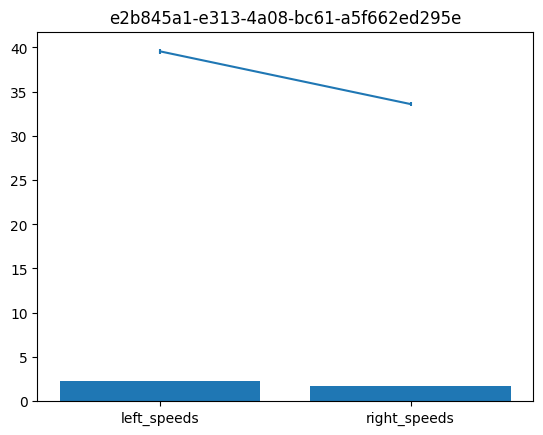

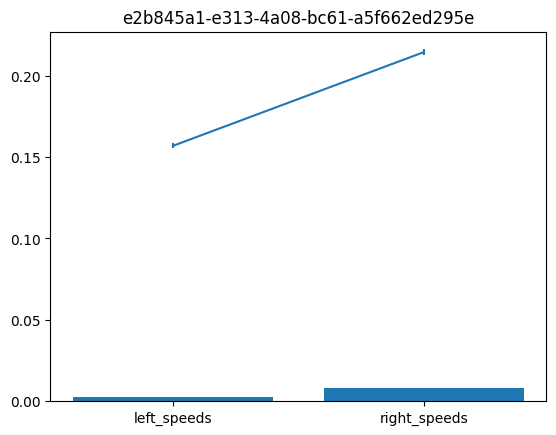

e2b845a1-e313-4a08-bc61-a5f662ed295e


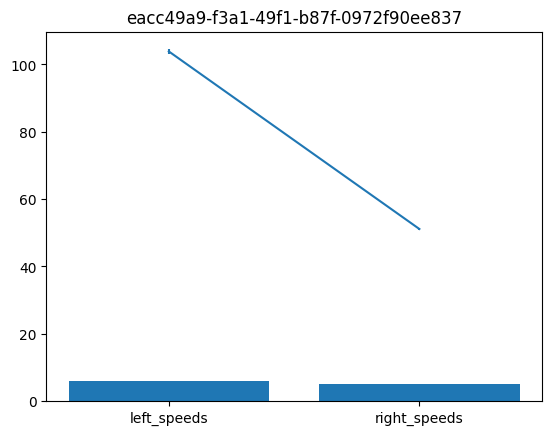

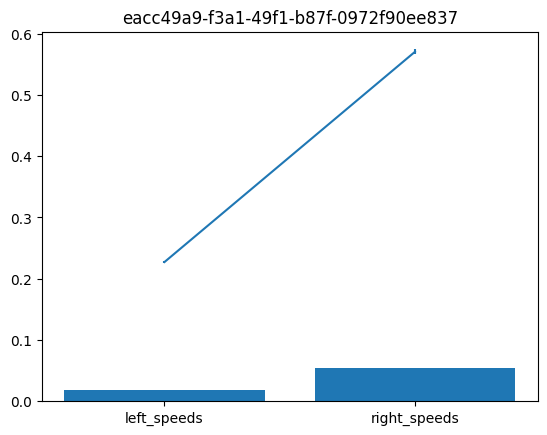

eacc49a9-f3a1-49f1-b87f-0972f90ee837


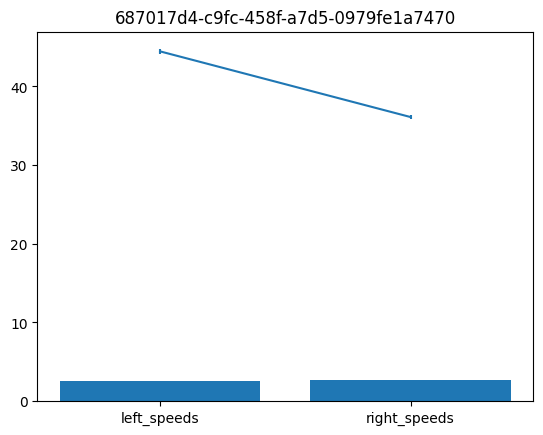

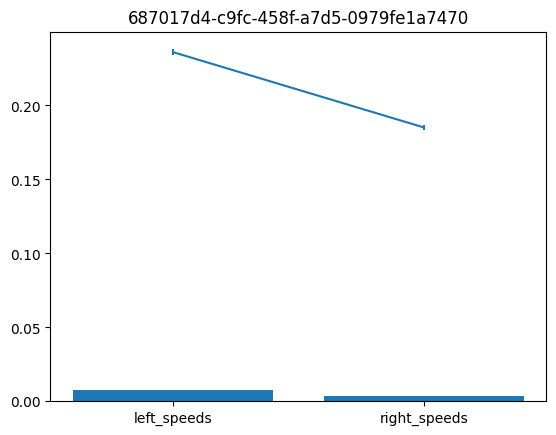

687017d4-c9fc-458f-a7d5-0979fe1a7470


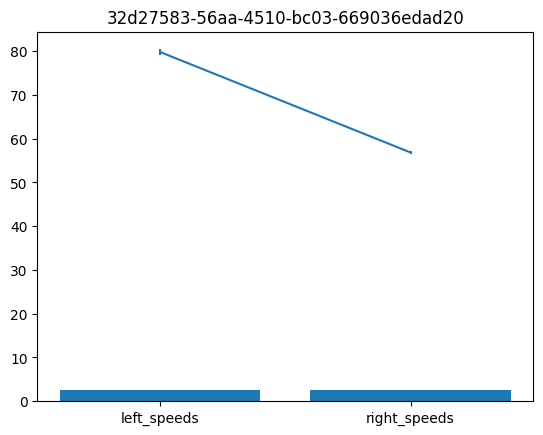

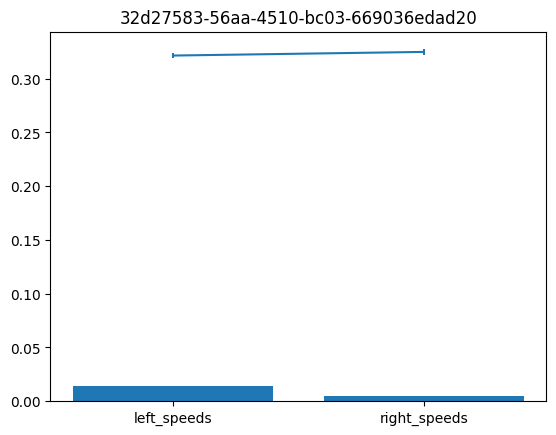

32d27583-56aa-4510-bc03-669036edad20


In [ ]:
paws = ['l_paw', 'r_paw']

for m, mat in enumerate(sessions_to_process[:10]):

    file_path = one.eid2path(mat)
    if prefix == '/home/ines/repositories/':
        mouse_name = file_path.parts[8]
    else:
        mouse_name = file_path.parts[7]

    session = mat
    filename = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)
    left_speeds = get_speed(design_matrix, design_matrix['Bin'], 'left', 30, split=True, feature='l_paw')
    right_speeds = get_speed(design_matrix, design_matrix['Bin'], 'left', 30, split=True, feature='r_paw')
    
    plt.bar(['left_speeds', 'right_speeds'],
            [np.nanmedian(np.abs(left_speeds[1])), np.nanmedian(np.abs(right_speeds[1]))])
    plt.errorbar(['left_speeds', 'right_speeds'],
            [np.nanmean(np.abs(left_speeds[1])), np.nanmean(np.abs(right_speeds[1]))],
            [np.nanstd(np.abs(left_speeds[1]))/np.sqrt(len(left_speeds[1])), np.nanstd(np.abs(right_speeds[1]))/np.sqrt(len(right_speeds[1]))])
    plt.title(mat)
    plt.show()
    plt.bar(['left_speeds', 'right_speeds'],
            [np.median(np.abs(design_matrix.loc[design_matrix['avg_wheel_vel']<0, 'avg_wheel_vel'])), 
             np.median(np.abs(design_matrix.loc[design_matrix['avg_wheel_vel']>0, 'avg_wheel_vel']))])
    plt.errorbar(['left_speeds', 'right_speeds'],
                 [np.mean(np.abs(design_matrix.loc[design_matrix['avg_wheel_vel']<0, 'avg_wheel_vel'])), 
                np.mean(np.abs(design_matrix.loc[design_matrix['avg_wheel_vel']>0, 'avg_wheel_vel']))], 
                 [np.nanstd(np.abs(design_matrix.loc[design_matrix['avg_wheel_vel']<0, 'avg_wheel_vel']))/np.sqrt(len(design_matrix.loc[design_matrix['avg_wheel_vel']<0, 'avg_wheel_vel'])), 
              np.nanstd(np.abs(design_matrix.loc[design_matrix['avg_wheel_vel']>0, 'avg_wheel_vel']))/np.sqrt(len(design_matrix.loc[design_matrix['avg_wheel_vel']>0, 'avg_wheel_vel']))])
    plt.title(mat)
    plt.show()
    print(mat)
        

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_45103/91921355.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1, 1].legend()
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_45103/91921355.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


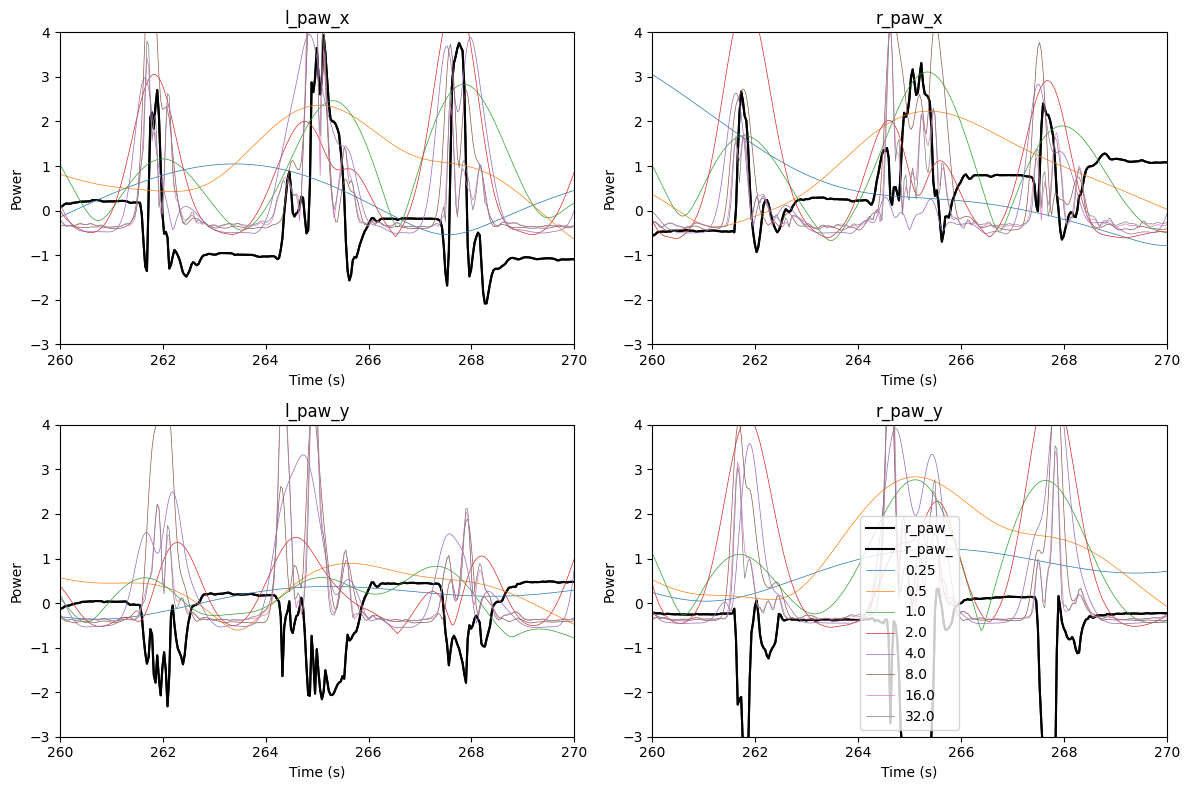

In [ ]:
init = 260
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
for v, var in enumerate(['l_paw_', 'r_paw_']):
    for c, coor in enumerate(['x', 'y']):
        ax[c, v].plot(design_matrix['Bin'], stats.zscore(design_matrix[var+coor], nan_policy='omit'), label=var, color='k')
        ax[c, v].plot(design_matrix['Bin'], stats.zscore(design_matrix[var+coor], nan_policy='omit'), label=var, color='k')
        # Wavelet transforms
        for i, frequency in enumerate(f):
            ax[c, v].plot(design_matrix['Bin'], stats.zscore(design_matrix[var+coor+str(frequency)], 
                                                             nan_policy='omit'), label=str(frequency), linewidth=.5)
            ax[c, v].set_xlim([init, init+10])
            ax[c, v].set_ylim([-3, 4])
            ax[c, v].set_ylabel('Power')
            ax[c, v].set_xlabel('Time (s)')
        ax[c, v].set_title(var+coor)
    ax[1, 1].legend()
    plt.tight_layout()

/tmp/ipykernel_12118/4288006091.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1, 1].legend()


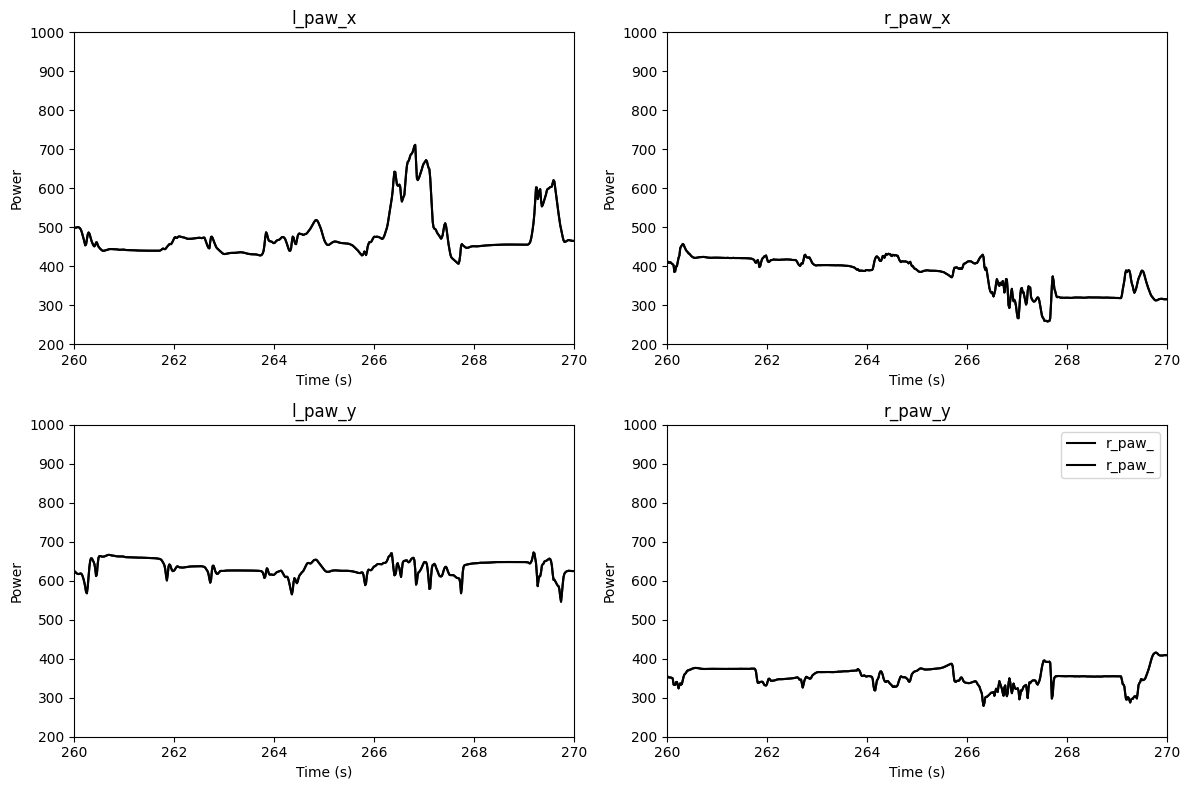

In [ ]:
init = 260
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
for v, var in enumerate(['l_paw_', 'r_paw_']):
    for c, coor in enumerate(['x', 'y']):
        ax[c, v].plot(design_matrix['Bin'], design_matrix[var+coor], label=var, color='k')
        ax[c, v].plot(design_matrix['Bin'], design_matrix[var+coor], label=var, color='k')

        ax[c, v].set_xlim([init, init+10])
        ax[c, v].set_ylim([200, 1000])
        ax[c, v].set_ylabel('Power')
        ax[c, v].set_xlabel('Time (s)')
        ax[c, v].set_title(var+coor)
    ax[1, 1].legend()
    plt.tight_layout()

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_45103/3896101047.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1, 1].legend()


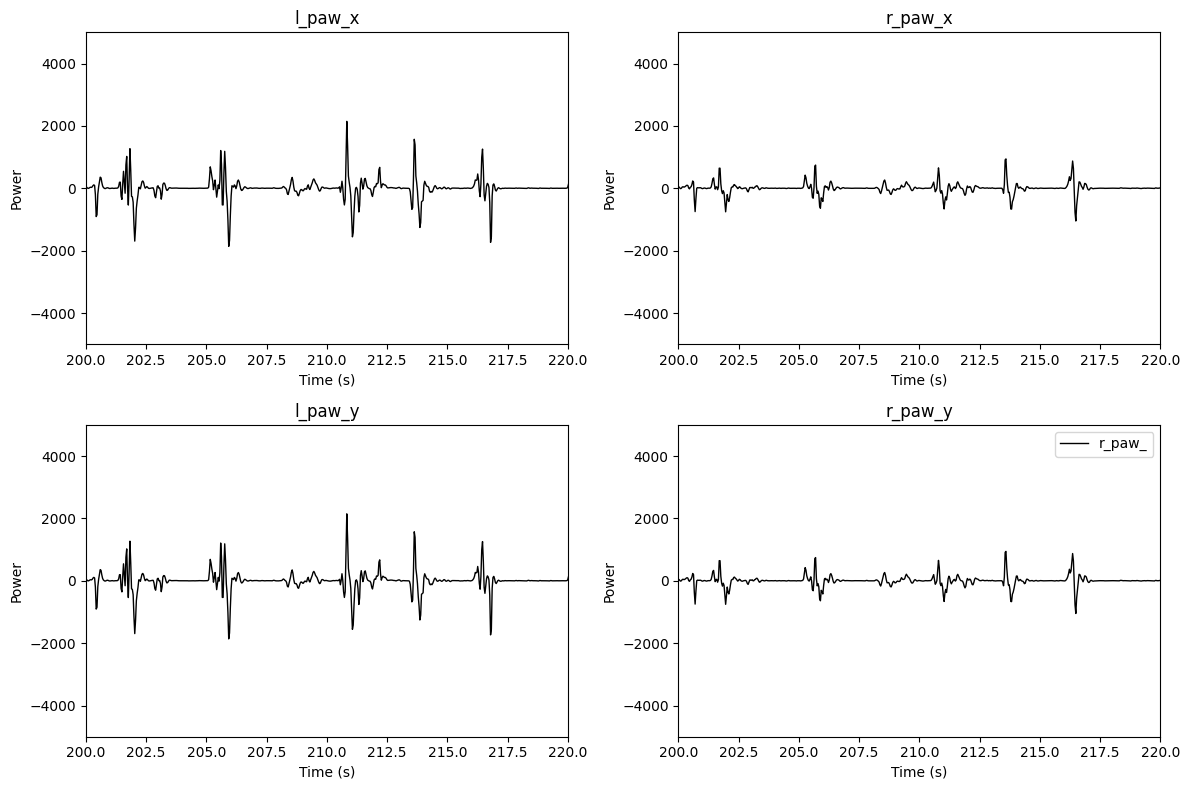

In [ ]:
init = 200
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
for v, var in enumerate(['l_paw_', 'r_paw_']):
    for c, coor in enumerate(['x', 'y']):
        # ax[c, v].plot(design_matrix['Bin'], stats.zscore(design_matrix[var+coor], nan_policy='omit'), label=var, color='k')
        # if var == 'l_paw_':
        #     ax[c, v].plot(design_matrix['Bin'], stats.zscore(left_speeds[1], nan_policy='omit'), label=var, color='k', linewidth=1)
        # elif var == 'r_paw_':
        #     ax[c, v].plot(design_matrix['Bin'], stats.zscore(right_speeds[1], nan_policy='omit'), label=var, color='k', linewidth=1)
        # ax[c, v].plot(design_matrix['Bin'], stats.zscore(design_matrix[var+coor], nan_policy='omit'), label=var, color='k')
        if var == 'l_paw_':
            ax[c, v].plot(design_matrix['Bin'], left_speeds[1], label=var, color='k', linewidth=1)
        elif var == 'r_paw_':
            ax[c, v].plot(design_matrix['Bin'], right_speeds[1], label=var, color='k', linewidth=1)
        # Wavelet transforms
        # for i, frequency in enumerate(f):
        #     # ax[c, v].plot(design_matrix['Bin'], stats.zscore(design_matrix[var+coor+str(frequency)], 
        #     #                                                  nan_policy='omit')+2, label=str(frequency), linewidth=.8)
        #     ax[c, v].plot(design_matrix['Bin'], design_matrix[var+coor+str(frequency)]+2, label=str(frequency), linewidth=.8)
        ax[c, v].set_xlim([init, init+20])
        ax[c, v].set_ylim([-5000, 5000])
        ax[c, v].set_ylabel('Power')
        ax[c, v].set_xlabel('Time (s)')
        ax[c, v].set_title(var+coor)
    ax[1, 1].legend()
    plt.tight_layout()